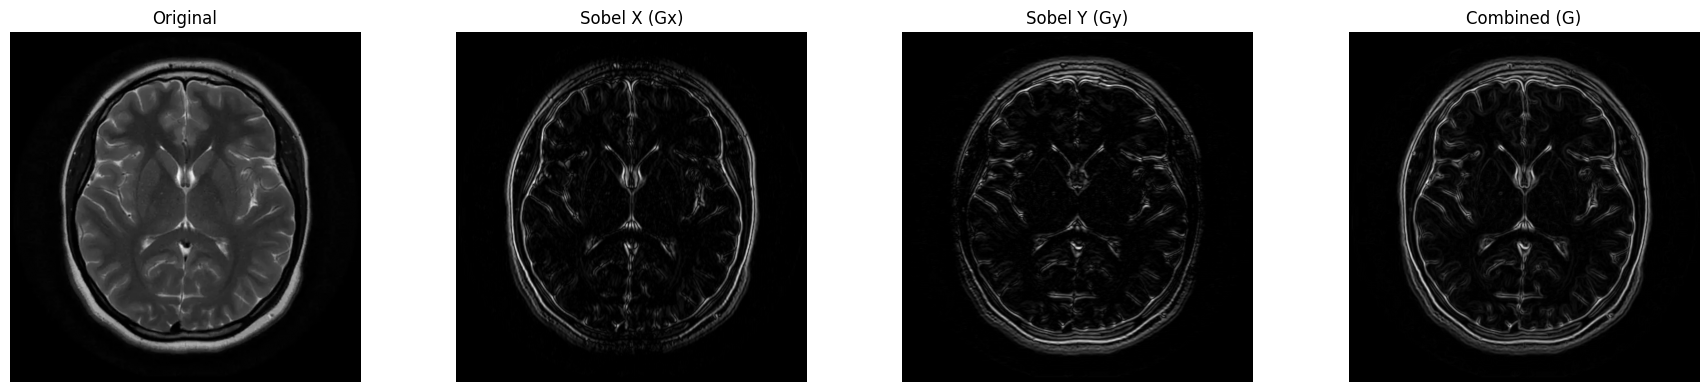

In [8]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt

os.chdir(r"C:\Users\ASUS\Desktop")

img  = cv2.imread("mri.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# ── Sobel ──────────────────────────────────
sobel_x    = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y    = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
combined   = np.sqrt(sobel_x**2 + sobel_y**2)

def norm(x):
    return np.uint8(np.abs(x) / np.abs(x).max() * 255)

# ── العرض ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(gray,          cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(norm(sobel_x), cmap='gray'); axes[1].set_title('Sobel X (Gx)')
axes[2].imshow(norm(sobel_y), cmap='gray'); axes[2].set_title('Sobel Y (Gy)')
axes[3].imshow(norm(combined),cmap='gray'); axes[3].set_title('Combined (G)')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

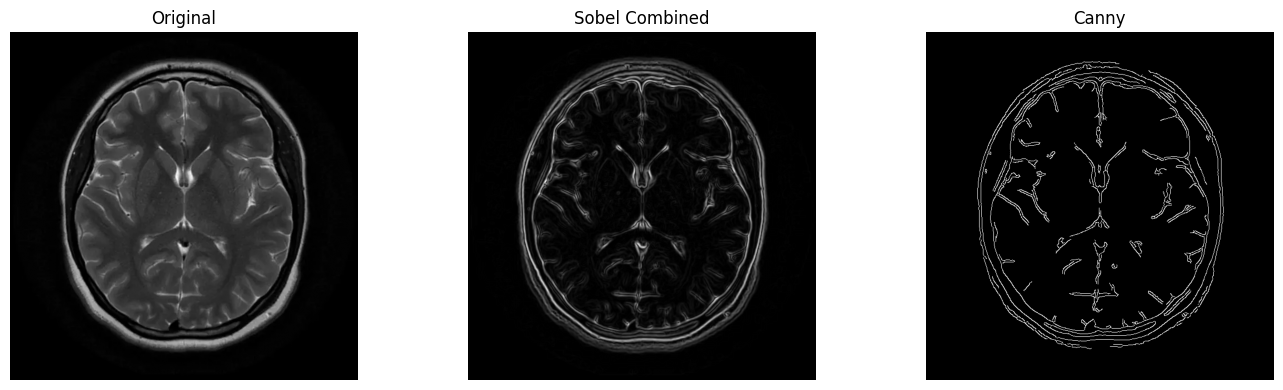

In [9]:
# ── Canny ──────────────────────────────────
canny = cv2.Canny(blur,
                  threshold1=50,   # عتبة دنيا
                  threshold2=150)  # عتبة عليا

# ── مقارنة Sobel vs Canny ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(gray,          cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(norm(combined),cmap='gray'); axes[1].set_title('Sobel Combined')
axes[2].imshow(canny,         cmap='gray'); axes[2].set_title('Canny')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

الحجم: (1411, 1411, 3)


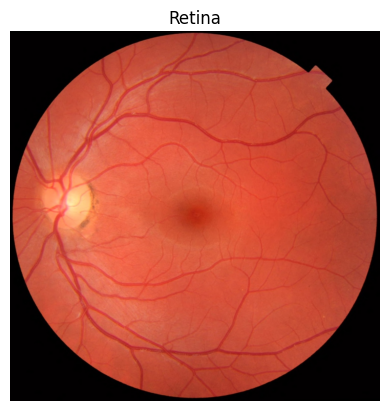

In [11]:
from skimage import data
import cv2
import numpy as np
import matplotlib.pyplot as plt

# صورة شبكية العين
retina = data.retina()
print("الحجم:", retina.shape)

plt.imshow(retina)
plt.title('Retina')
plt.axis('off')
plt.show()

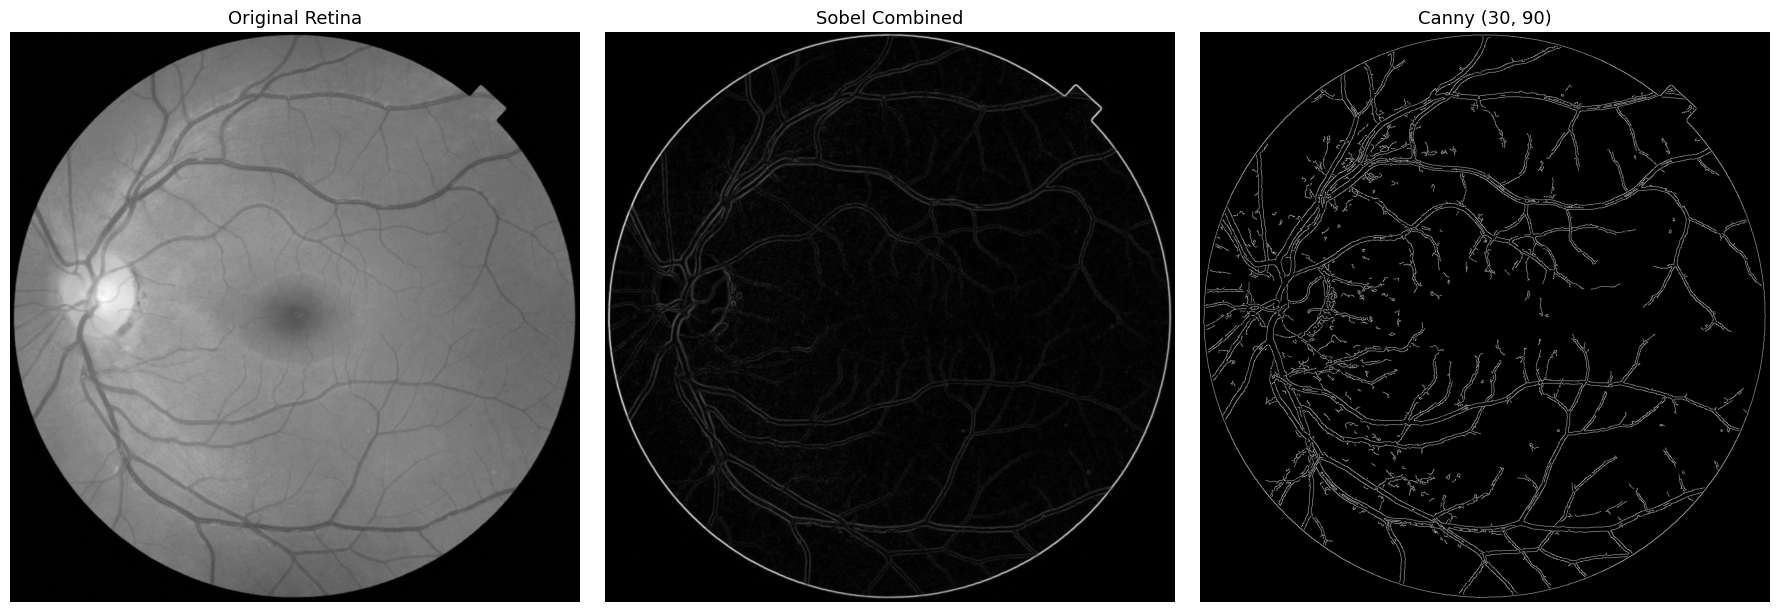

In [21]:
from skimage import data
import cv2
import numpy as np
import matplotlib.pyplot as plt

# صورة شبكية العين
retina = data.retina()

# تحويل لرمادي
gray = cv2.cvtColor(retina, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# ── Sobel ──────────────────────────────────
sobel_x  = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y  = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
combined = np.sqrt(sobel_x**2 + sobel_y**2)
def norm(x): return np.uint8(np.abs(x)/np.abs(x).max()*255)

# ── Canny ──────────────────────────────────
canny = cv2.Canny(blur, 10, 30)

# ── العرض ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(gray,           cmap='gray')
axes[0].set_title('Original Retina', fontsize=13)

axes[1].imshow(norm(combined), cmap='gray')
axes[1].set_title('Sobel Combined', fontsize=13)

axes[2].imshow(canny,          cmap='gray')
axes[2].set_title('Canny (30, 90)', fontsize=13)

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()